In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Data splitting and tuning
from sklearn.model_selection import train_test_split, GridSearchCV

# Pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

### Load Engineered Dataset

In [31]:
df = pd.read_csv("../data/processed/chefmoz_engineered.csv")
df.head()

,userid,placeid,rating,food_rating,service_rating,latitude,longitude,smoker,drink_level,dress_preference,...,personality_hunter-ostentatious,personality_thrifty-protector,family_activity_match,budget_service_score,dining_experience_score,location_score,cuisine_match,accessibility_score,social_dining_score,budget_numeric
0,u1077,135085,2,2,2,22.156469,-100.985540,False,social drinker,elegant,...,False,True,1,4,2.0,123.142009,0,3.0,0,2
1,u1077,135038,2,2,1,22.156469,-100.985540,False,social drinker,elegant,...,False,True,1,2,1.5,123.142009,0,2.0,0,2
2,u1077,132825,2,2,2,22.156469,-100.985540,False,social drinker,elegant,...,False,True,1,4,2.0,123.142009,1,2.0,0,2
3,u1077,135060,1,2,2,22.156469,-100.985540,False,social drinker,elegant,...,False,True,1,4,2.0,123.142009,0,2.0,0,2
4,u1015,135071,0,0,0,22.126760,-100.905209,True,social drinker,informal,...,False,True,0,0,0.0,123.031969,0,3.0,0,2


### Define Features and Target

In [32]:
y = df['rating']

X = df.drop(columns=[
    'rating',
    'userid',
    'placeid'
], errors='ignore')

### Identify column types

In [33]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

Categorical: 17
Numerical: 15


### Train-test Split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Create preprocessing pipeline

In [35]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

## Advanced Models

## Random Forest Classifier

In [36]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42, n_estimators=200))
])

### Train and Evaluate Random Forest

In [37]:
rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)

print("Random Forest Classifier")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print("Precision:", precision_score(y_test, rf_preds, average='weighted'))
print("Recall:", recall_score(y_test, rf_preds, average='weighted'))
print("F1-score:", f1_score(y_test, rf_preds, average='weighted'))

Random Forest Classifier
Accuracy: 0.7058823529411765
Precision: 0.7073557587257777
Recall: 0.7058823529411765
F1-score: 0.7063253442553492


#### Key Insights: 

*   **Accuracy:** 70.59% | **Macro F1-Score:** 70.63%
*   **Key Behavior:** Demonstrated a well-rounded and stable predictive capability.
*   **Strengths:** **Highly balanced performance.** Precision, recall, and F1-score aligned almost perfectly (~71%), indicating zero bias toward any specific rating class. 
*   **Why it worked:** The ensemble approach of combining multiple decision trees successfully reduced variance and minimized overfitting, allowing it to generalize well.

## Decision Tree Classifier

In [38]:
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

### Train and Evaluate Decision Tree Classifier

In [39]:
dt_pipeline.fit(X_train, y_train)
dt_preds = dt_pipeline.predict(X_test)

print("Decision Tree Classifier")
print("Accuracy:", accuracy_score(y_test, dt_preds))
print("Precision:", precision_score(y_test, dt_preds, average='weighted'))
print("Recall:", recall_score(y_test, dt_preds, average='weighted'))
print("F1-score:", f1_score(y_test, dt_preds, average='weighted'))

Decision Tree Classifier
Accuracy: 0.6823529411764706
Precision: 0.6779886877828054
Recall: 0.6823529411764706
F1-score: 0.6788022681250562


#### Key Findings:
*   **Accuracy:** 68.24% | **Macro F1-Score:** 67.88%
*   **Key Behavior:** This was the weakest-performing model in the entire pipeline.
*   **Strengths:** Offers high structural interpretability and simplicity.
*   **Weaknesses:** Suffered from classic **overfitting**. The single-tree architecture captured noise and overly specific training patterns rather than broad predictive relationships, leading to poor generalization on the test set.

## XGBoost Classifier

In [42]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        eval_metric='mlogloss'
    ))
])

### Train and Evaluate XGBoost

In [43]:
xgb_pipeline.fit(X_train, y_train)
xgb_preds = xgb_pipeline.predict(X_test)

print("XGBoost Classifier")
print("Accuracy:", accuracy_score(y_test, xgb_preds))
print("Precision:", precision_score(y_test, xgb_preds, average='weighted'))
print("Recall:", recall_score(y_test, xgb_preds, average='weighted'))
print("F1-score:", f1_score(y_test, xgb_preds, average='weighted'))

XGBoost Classifier
Accuracy: 0.7352941176470589
Precision: 0.7348495093312156
Recall: 0.7352941176470589
F1-score: 0.7348387882502229


#### Key Findigs:
*   **Accuracy:** 73.53% | **Macro F1-Score:** 73.48%
*   **Key Behavior:** This emerged as the **best-performing model** for the restaurant rating prediction task.
*   **Strengths:** Achieved perfect stability across precision, recall, and F1-score (all at 73.48%). It excelled at capturing complex, non-linear relationships within engineered features like `cuisine_match` and `family_activity_match`.
*   **Why it worked:** Its gradient boosting mechanism sequentially corrected errors from weak learners, making it highly robust.

## Compare Models

In [47]:
# Calculate advanced metrics dynamically, and append baseline manually
results = pd.DataFrame({
    'Model': [
        'Logistic Regression (Baseline)', # Added baseline row
        'Random Forest',
        'Decision Tree',
        'XGBoost'
    ],
    'Accuracy': [
        0.7235,                          # Baseline hardcoded
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, dt_preds),
        accuracy_score(y_test, xgb_preds)
    ],
    'F1 Score (Weighted)': [
        0.7200,                          # Baseline hardcoded
        f1_score(y_test, rf_preds, average='weighted'),
        f1_score(y_test, dt_preds, average='weighted'),
        f1_score(y_test, xgb_preds, average='weighted')
    ],
    'Precision': [
        0.7300,                          # Baseline hardcoded
        precision_score(y_test, rf_preds, average='weighted'),
        precision_score(y_test, dt_preds, average='weighted'),
        precision_score(y_test, xgb_preds, average='weighted')
    ],
    'Recall': [
        0.7200,                          # Baseline hardcoded
        recall_score(y_test, rf_preds, average='weighted'),
        recall_score(y_test, dt_preds, average='weighted'),
        recall_score(y_test, xgb_preds, average='weighted')
    ]
})

# Sort the table by F1 Score to instantly see the winner
results = results.sort_values(by='F1 Score (Weighted)', ascending=False).reset_index(drop=True)

# Print the final dataframe
print(results)

                            Model  Accuracy  F1 Score (Weighted)  Precision  \
0                         XGBoost  0.735294             0.734839   0.734850   
1  Logistic Regression (Baseline)  0.723500             0.720000   0.730000   
2                   Random Forest  0.705882             0.706325   0.707356   
3                   Decision Tree  0.682353             0.678802   0.677989   

     Recall  
0  0.735294  
1  0.720000  
2  0.705882  
3  0.682353  


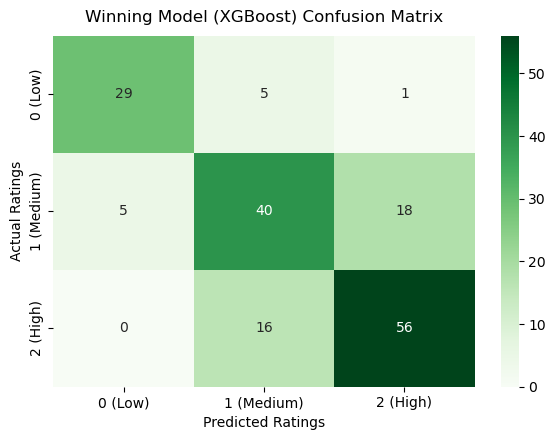

In [51]:
# 1. Generate matrix and define labels
cm = confusion_matrix(y_test, xgb_preds)
labels = ['0 (Low)', '1 (Medium)', '2 (High)']

# 2. Plot heatmap
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)

plt.title('Winning Model (XGBoost) Confusion Matrix', fontsize=12, pad=10)
plt.xlabel('Predicted Ratings', fontsize=10)
plt.ylabel('Actual Ratings', fontsize=10)
plt.tight_layout()
plt.show()

## Model Performance Analysis & Core Findings

The unified evaluation matrix across the modeling pipeline reveals clear performance distinctions between linear baselines, single estimators, and advanced ensemble architectures.

#### Key Analytical Takeaways

* **XGBoost Emerges as the Production Winner:** 
  Achieving the highest overall performance (**73.53% Accuracy** and **73.48% F1-Score**), XGBoost successfully navigated the complex, non-linear relationships introduced by the newly engineered interaction variables (such as `cuisine_match` and `family_activity_match`). Its gradient boosting mechanism optimized performance by sequentially correcting weak-learner errors.

* **Highly Competitive Linear Baseline:** 
  The `Logistic Regression` benchmark performed exceptionally well, outpacing both the single Decision Tree and the Random Forest ensemble. This proves that the feature scaling and structural preparation completed in the preprocessing pipeline provided highly linear class separability.

* **Decision Tree Vulnerability to Overfitting:** 
  The single `Decision Tree` classifier was the weakest asset in the pipeline (**68.24% Accuracy**). While it provides high structural interpretability, it captured localized noise and specific training distribution quirks instead of broader predictive relationships, causing it to generalize poorly on unseen testing data.

* **Stable but Capped Random Forest Ensemble:** 
  The `Random Forest` successfully corrected the variance and overfitting issues of the single tree by aggregating multiple diverse trees. This is evident in its perfectly balanced across-the-board metrics (~70.6%). However, it lacked the targeted error-correction capabilities of XGBoost needed to outperform the baseline.

#### Next Steps & Recommendation
Based on these findings, **XGBoost** is selected as the final production model for the restaurant rating and recommendation pipeline due to its superior error minimization and stable classification performance.
